# Analyze simulation results

## Import libraries

In [1]:
import re
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.image as AxesImage
import numpy as np
from matplotlib.colors import LogNorm
# from matplotlib.colors import Normalize

import pyc2ray as pc2r

results_dir = Path("/home/tboschi/Code/ARTS4SKA/Hesim/results_debug")

sim = pc2r.C2Ray_Test(results_dir / "parameters_c2ray.yml")

Key 'Sources' not found in parameter configuration. Using default values.



                 _________   ____
    ____  __  __/ ____/__ \ / __ \____ ___  __
   / __ \/ / / / /    __/ // /_/ / __ `/ / / /
  / /_/ / /_/ / /___ / __// _, _/ /_/ / /_/ /
 / .___/\__, /\____//____/_/ |_|\__,_/\__, /
/_/    /____/                        /____/

Log file for pyC2Ray.


Welcome! Mesh size is N = 100.
Simulation Box size (comoving Mpc): 1.000e+01
Cosmology is off.
Using power-law opacity with 2000 table points between tau=10^(-20) and tau=10^(4)
Using Black-Body sources with effective temperature T = 5.0e+04 K and Radius 1.621e+00 rsun
Spectrum Frequency Range: {freq_min:.3e} to {freq_max:.3e} Hz
This is Energy:           {freq_min / c.ev2hz:.3e} to {freq_max / c.ev2hz:.3e} eV
Integrating photoionization rate tables...
Integrating photoheating rate tables...
Successfully copied radiation tables to GPU memory.
Successfully copied cooling tables to GPU memory.

---- Calculated Clumping Factor (constant model):
 min, mean and max clumping : 1.000e+00  1.000e+00  1.000e+00

## Plot simulation results

In [2]:
def get_zreds() -> list[float]:
    """Get decreasing list of redshifts from the results folder."""
    pattern = re.compile(r"^xfrac_z(\d+\.\d{3})\.npz$")

    z_values = []
    for p in results_dir.glob("xfrac_z*.npz"):
        if m := pattern.match(p.name):
            z_values.append(float(m.group(1)))

    return sorted(z_values, reverse=True)

In [3]:
def load_slices(z: float, filetype: str) -> dict[str, np.ndarray]:
    return np.load(results_dir / f"{filetype}_z{z:.3f}.npz")
    
def plot_slices(z: float, data: dict[str, np.ndarray], type_label: str, log_scale: bool = True, cmap: str = "jet", crange: None | tuple[float, float] = None, zoom: float = 2) -> None:
    # Calculate zoom
    m = sim.N // 2
    f = int(m / zoom)
    s = slice(m - f, m + f), slice(m - f, m + f), m

    # Plot extent
    Lx, Ly = sim.boxsize, sim.boxsize
    extent = [0, Lx, 0, Ly]

    # Shared color normalization
    if crange is None:
        vmin = max(1e-100, min(np.nanmin(a) for a in data.values()))
        vmax = max(1e-100, max(np.nanmax(a) for a in data.values()))
        crange = vmin, vmax

    assert crange is not None
    vmin, vmax = crange
    norm = LogNorm(vmin=vmin, vmax=vmax) if log_scale else Normalize(vmin=vmin, vmax=vmax)

    fig, axs = plt.subplots(1, len(data), figsize=(12, 5), constrained_layout=True)

    ims: list[AxesImage] = []
    for ax, (lab, arr) in zip(axs, data.items()):
        im = ax.imshow(
            arr[s],
            cmap=cmap,
            norm=norm,
            origin="lower",
            extent=extent,
        )
        ax.set_title(lab)
        ax.set_xlabel("x [cMpc/h]")
        ax.set_ylabel("y [cMpc/h]")
        ax.set_aspect("equal")
        ims.append(im)

    fig.suptitle(f"z = {z:.3f}")
    cbar = fig.colorbar(ims[0], ax=axs, pad=0.02, shrink=0.9)
    cbar.set_label(type_label)

    plt.show()

In [4]:
zreds = get_zreds()
print(zreds)

[9.0, 8.884, 8.771, 8.662, 8.556]


9.999999999999996e-21 9.999999999999996e-21 9.999999999999996e-21


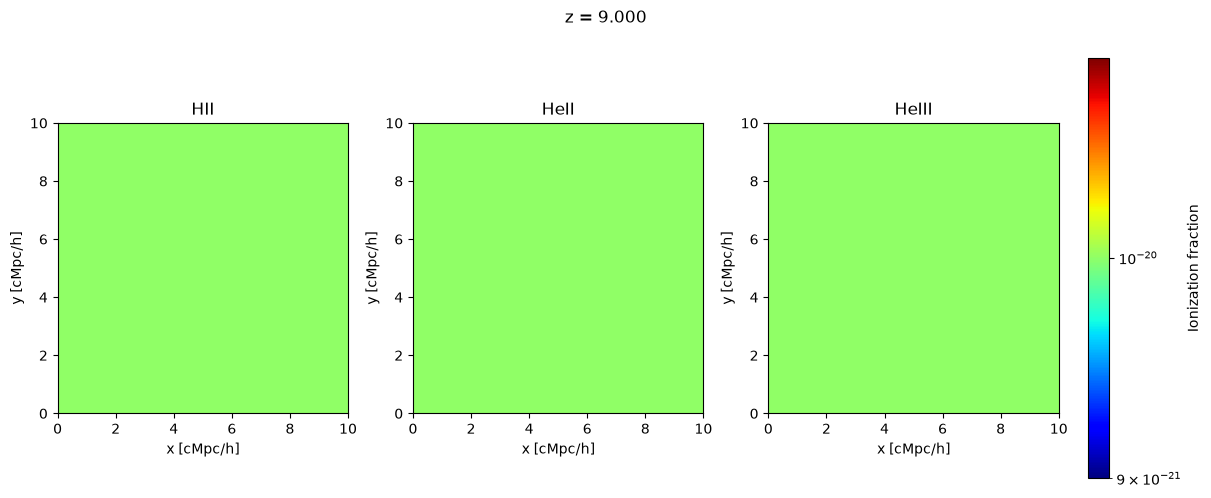

8.538838495874989e-06 8.53086752677321e-06 9.142214769264722e-08


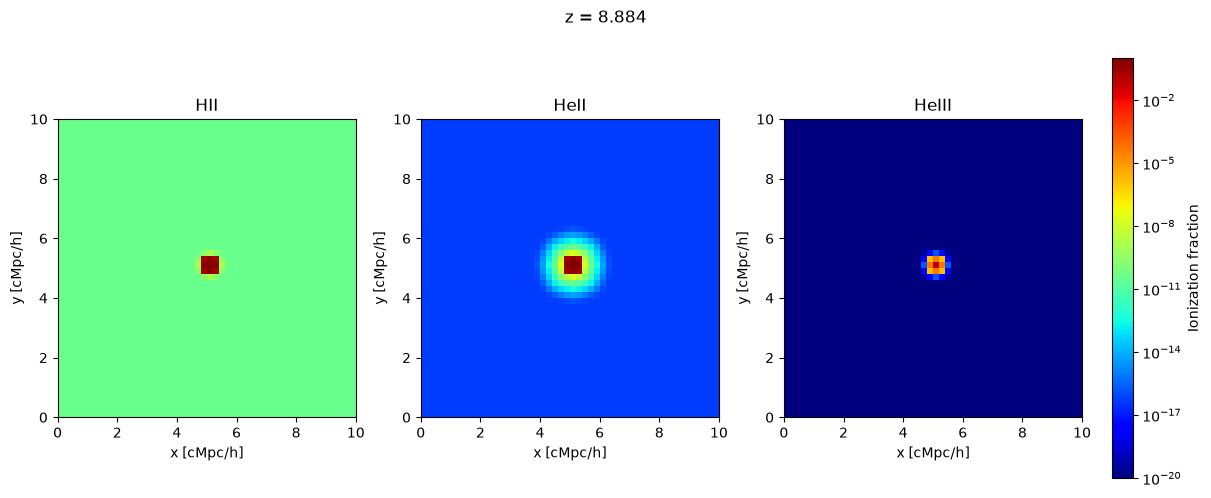

1.695473116936082e-05 1.633985993042421e-05 1.7901160326054533e-07


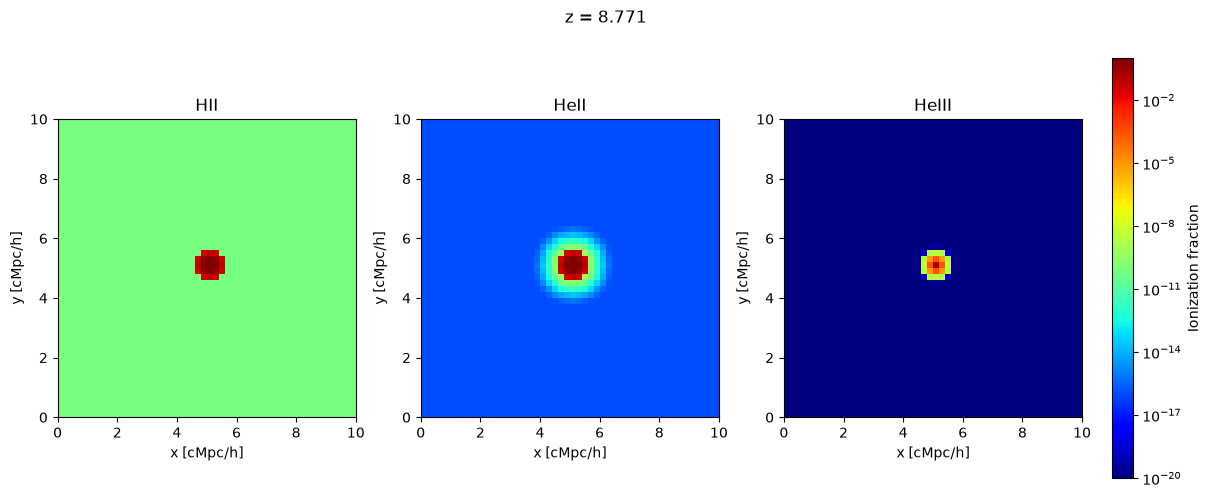

2.5339108974224707e-05 2.3775241995206512e-05 2.6076644295634587e-07


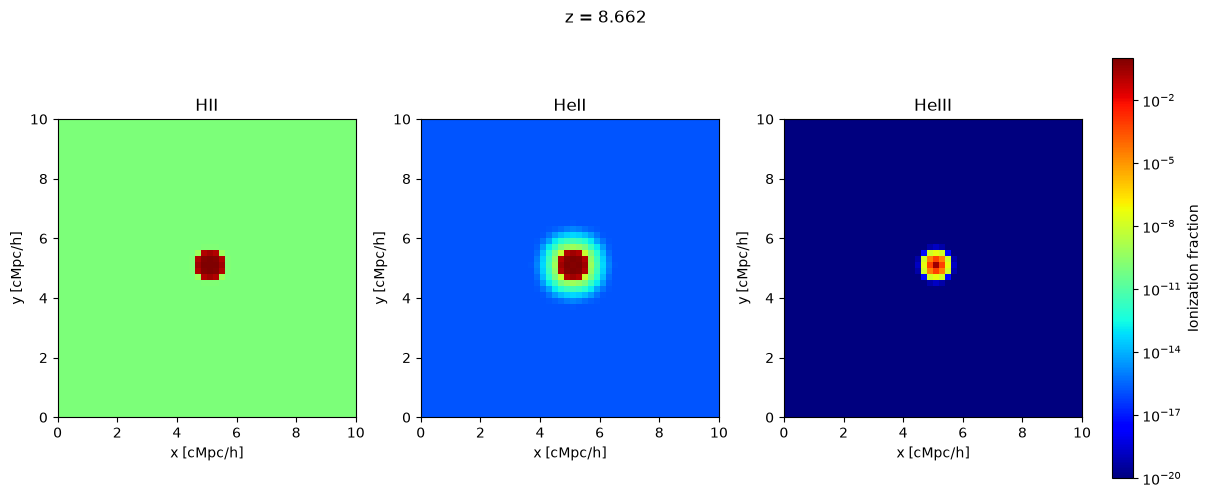

3.3553814360648376e-05 3.129872150678872e-05 3.376286384460339e-07


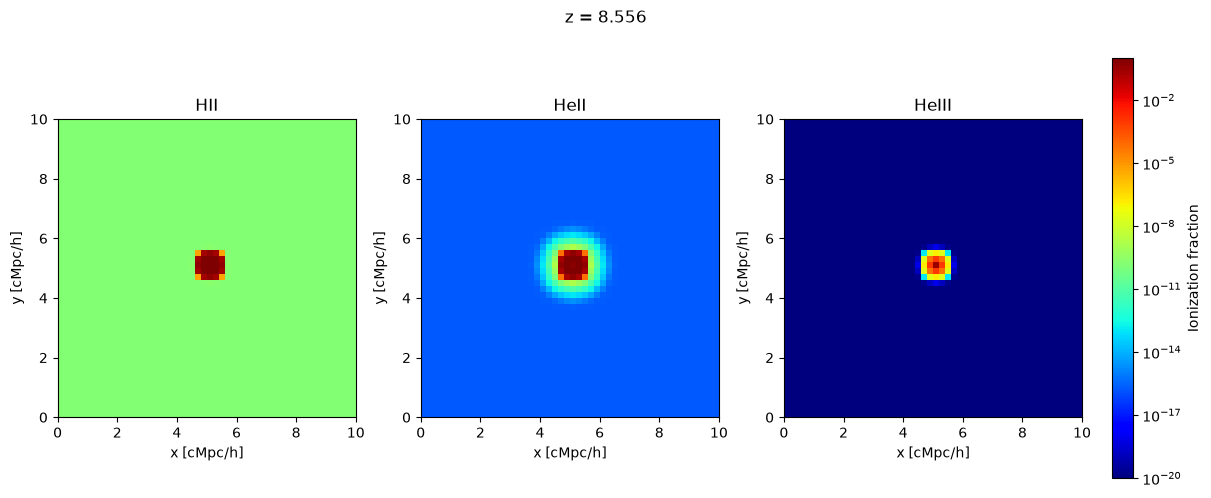

In [6]:
for z in zreds:
    data = load_slices(z, "xfrac")
    print(data["HII"].mean(), data["HeII"].mean(), data["HeIII"].mean())
    plot_slices(z, data, "Ionization fraction")

In [9]:
import math

def create_zred_array(num_zred: int = 5, zred0: float = 9.0, dt: float = 1e7, H0: float = 0.7, Omega0: float = 0.27) -> list[float]:
    """
    Construct a redshift sequence from a starting redshift and fixed time step.

    Valid only in the high-z approximation (matter-dominated, flat cosmology).

    Parameters
    ----------
    num_zred : int
        Number of redshift slices.
    zred0 : float
        Initial redshift.
    dt : float
        Time step between slices, in years (converted to seconds internally).
    H0 : float
        Hubble constant, in 1/s.
    Omega0 : float
        Matter density parameter.

    Returns
    -------
    zred_array : list
        Array of length num_zred with the redshift at each slice.
    """
    zred_array = [zred0]

    # Convert timestep in seconds
    dt *=  3.15576E+07

    # Hubble constant in cgs
    H0 *= 10.0 / 3.086e18

    # Cosmological time corresponding to the initial redshift (high-z only)
    t0 = 2.0 * math.pow(1.0 + zred0,  -1.5) / (3.0 * H0 * math.sqrt(Omega0))

    for nz in range(1, num_zred):
        zred = -1.0 + (1.0 + zred0) * (t0 / (t0 + nz * dt)) ** (2.0 / 3.0)
        zred_array.append(zred)

    return zred_array

In [18]:
print(create_zred_array(dt=5e6))

[9.0, 8.941618057749178, 8.884080832643278, 8.82736893766525, 8.771463592384155]


## Compare against analytical solution

In [14]:
def numerical_solution() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    zred_array = get_zreds()

    # get time of the corresponding redshift step
    times = (sim.cosmology.age(zred_array) - sim.cosmology.age(sim.zred_0)).to("Myr")

    # get half box length for interpolation in kpc
    m = sim.N // 2
    xc = np.linspace(0, sim.boxsize * 1000 / 2, m)

    # get numerical radius and velocity
    radii = np.zeros(len(zred_array))
    velocities = np.zeros(len(zred_array) - 1)

    for k, z in enumerate(zred_array):
        # load ionized fraction
        data = np.load(results_dir / f"xfrac_z{z:.3f}.npz")
        xHII = data["HII"]

        # line of sight from the center to the box side
        los = xHII[m:, m, m]

        # Compute the I-front radius at 50% ionized
        radii[k] = np.interp(0.5, np.flip(los), np.flip(xc))

        # Compute the I-front velocity
        if k > 0:
            continue
        velocities[k - 1] = (
            ((radii[k] - radii[k - 1]) / (times[k] - times[k - 1]) * u.kpc)
            .to("km/s")
            .value
        )

    return times, radii, velocities

In [15]:
time_n, radii_n, vel_n = numerical_solution()

In [18]:
def analytical_solution(
    t_evol: float, flux_strength: float = 1e54, avg_dens=1.87e-7
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    times = np.linspace(0, t_evol * u.yr, 200, endpoint=True).to("Myr")

    nGamma = flux_strength / u.s
    nH = avg_dens / u.cm**3
    alpha_B = sim.chem_params.bh00 * u.cm**3 / u.s
    clump = sim.sinks_params.clumping

    r0 = ((3 * nGamma / (4 * np.pi * clump * alpha_B * nH**2)) ** (1.0 / 3)).to("kpc")
    trec = (1.0 / (clump * alpha_B * nH)).to("Myr")

    taus = np.exp(-times / trec)

    radii = r0 * np.pow(1.0 - taus, 1.0 / 3.0)
    velocities = r0 / (3.0 * trec) * taus / np.pow(1.0 - taus, 2.0 / 3.0)

    return times.value, radii.to("kpc").value, velocities[1:].to("km/s").value

In [19]:
time_a, radii_a, vel_a = analytical_solution(5e8)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True)

axs[0].plot(time_a, radii_a, color='black', ls='-', label="Analytical", lw=2)
axs[0].plot(time_n, radii_n, color='tab:blue', marker='o', ls='--', label="Numerical", lw=2)
axs[0].set_ylabel("$r_I(t)$ [kpc]")

axs[1].semilogy(t_analytical[1:],v_analytical,color='black',label="Analytical",lw=2)
axs[1].plot(t_aveg, v_num, color='tab:blue', marker='o', ls='--', label="Numerical", lw=2)
axs[1].set_ylabel("$v_I(t)$ [km s$^{-1}$]")

for ax in axs:
    ax.set_xlabel("$t$ [Myr]")
    ax.grid()
    ax.legend()